/tmp/ipykernel_120034/3305155817.py:141: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


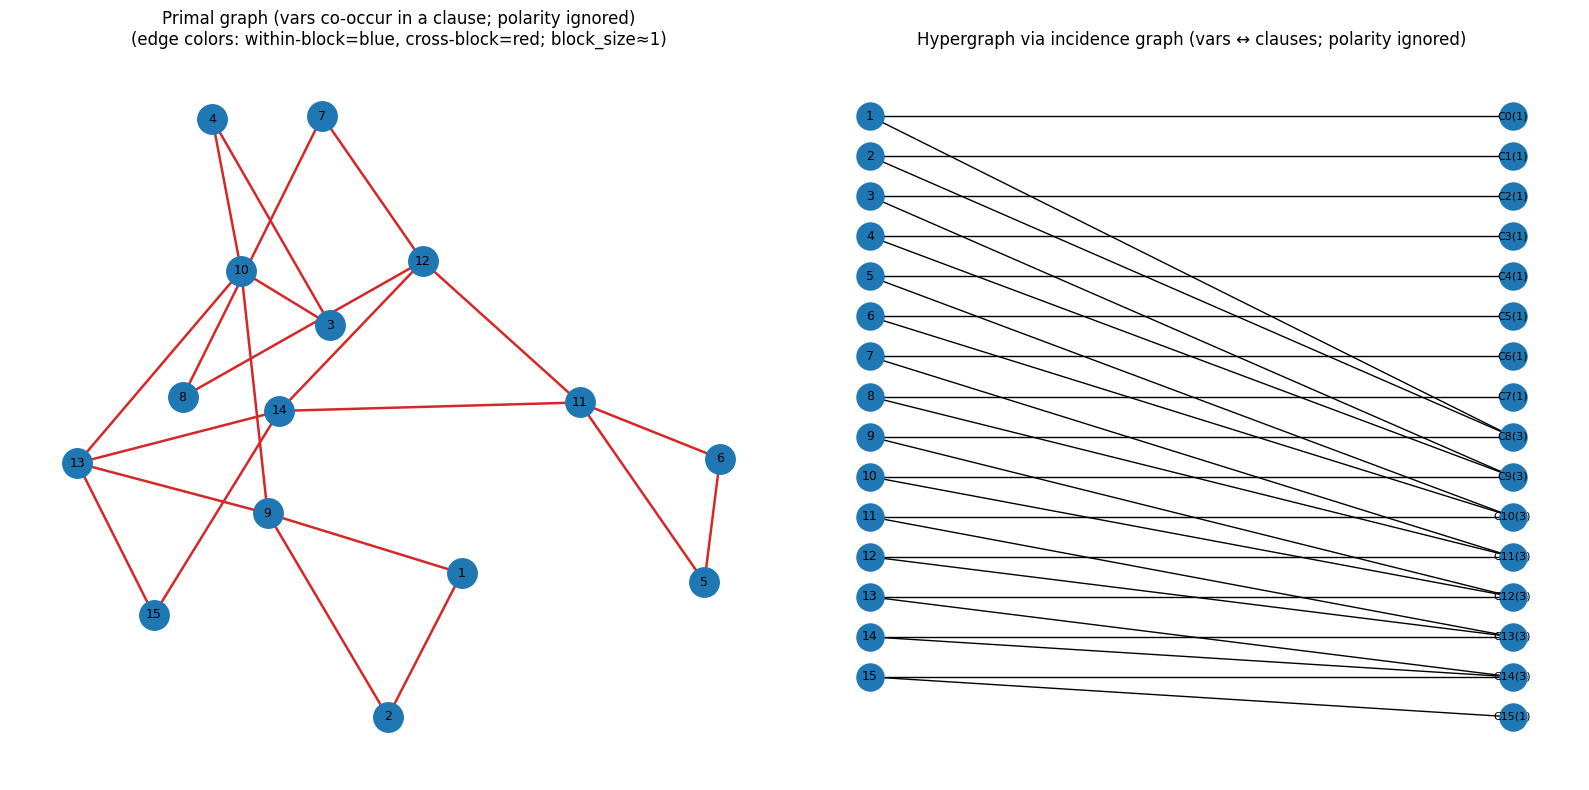

(<networkx.classes.graph.Graph at 0x7dc504dc6410>,
 <networkx.classes.graph.Graph at 0x7dc504dc5a20>)

In [3]:
# Fixed + robust CNF visualization (primal graph + hypergraph via incidence graph)
# Polarity ignored: coexist/co-occur uses abs(literal).

from __future__ import annotations

from typing import List, Optional, Sequence, Dict, Tuple
from collections import Counter
from cnf import *
import matplotlib.pyplot as plt

try:
    import networkx as nx
except ImportError as e:
    raise ImportError("Requires networkx. In a notebook run: !pip install networkx") from e


def infer_num_vars(clauses: List[List[int]]) -> int:
    return max((abs(l) for c in clauses for l in c), default=0)


def build_primal_graph(
    clauses: List[List[int]],
    *,
    weighted: bool = True,
) -> nx.Graph:
    """
    Primal graph:
      - nodes: variables 1..n
      - edge (u,v): u and v appear together in a clause (polarity ignored)
      - weight: number of clauses where {u,v} co-occur (if weighted=True)
    """
    n = infer_num_vars(clauses)
    G = nx.Graph()
    G.add_nodes_from(range(1, n + 1))

    co = Counter()
    for c in clauses:
        vs = sorted(set(abs(l) for l in c))
        for i in range(len(vs)):
            for j in range(i + 1, len(vs)):
                co[(vs[i], vs[j])] += 1

    for (u, v), w in co.items():
        if weighted:
            G.add_edge(u, v, weight=w)
        else:
            G.add_edge(u, v)

    return G


def build_incidence_graph(
    clauses: List[List[int]],
) -> nx.Graph:
    """
    Hypergraph visualization via incidence graph:
      - variable nodes: "v:1", ..., "v:n"
      - clause nodes: "c:0", ..., "c:m-1"
      - edge between clause node and each variable appearing in that clause (polarity ignored)
    Stores attributes:
      - kind in {"var","clause"}
      - var_id (int) for var nodes
      - clause_id (int) and clause_size (int) for clause nodes
    """
    n = infer_num_vars(clauses)
    B = nx.Graph()

    for v in range(1, n + 1):
        B.add_node(f"v:{v}", kind="var", var_id=v)

    for ci, c in enumerate(clauses):
        cn = f"c:{ci}"
        vs = sorted(set(abs(l) for l in c))
        B.add_node(cn, kind="clause", clause_id=ci, clause_size=len(vs))
        for v in vs:
            B.add_edge(f"v:{v}", cn)

    return B


def visualize_cnf_graphs(
    clauses: List[List[int]],
    *,
    primal_weighted: bool = True,
    show_primal_weights: bool = True,
    max_label_vars: int = 60,
    primal_layout: str = "spring",   # "spring" | "kamada_kawai" | "spectral"
    seed: int = 0,
    figsize: Tuple[int, int] = (16, 8),
) -> Tuple[nx.Graph, nx.Graph]:
    """
    Draws:
      (1) Primal graph (variables only)
      (2) Hypergraph via incidence graph (variables ↔ clauses)

    Structured primal-edge coloring (PHP-style):
      - blue  : edges within the same pigeon block (size inferred if possible)
      - red   : edges across blocks (hole constraints)
      - gray  : fallback if block-size inference fails

    Edge labels: only edges with weight > 1 (and only if weighted).
    """
    if not clauses:
        raise ValueError("clauses is empty")

    Gp = build_primal_graph(clauses, weighted=primal_weighted)
    Bi = build_incidence_graph(clauses)

    # --- Infer "pigeon block size" if possible (works for PHP-like encodings) ---
    # Heuristic: take the maximum clause width among positive-only clauses as block size.
    pos_clause_sizes = [len(set(abs(l) for l in c)) for c in clauses if all(l > 0 for l in c)]
    block_size = max(pos_clause_sizes) if pos_clause_sizes else None

    layout_fns = {
        "spring": lambda G: nx.spring_layout(G, seed=seed, k=1.2),
        "kamada_kawai": lambda G: nx.kamada_kawai_layout(G),
        "spectral": lambda G: nx.spectral_layout(G),
    }
    if primal_layout not in layout_fns:
        raise ValueError(f"Unknown primal_layout={primal_layout!r}. Use {list(layout_fns)}.")

    fig, axs = plt.subplots(1, 2, figsize=figsize)

    # ---------------- (1) Primal graph ----------------
    ax = axs[0]
    pos = layout_fns[primal_layout](Gp)

    nx.draw_networkx_nodes(Gp, pos, ax=ax, node_size=450)

    # Structured edge coloring
    edges = list(Gp.edges())
    edge_colors = []
    for u, v in edges:
        if block_size and (u - 1) // block_size == (v - 1) // block_size:
            edge_colors.append("tab:blue")  # within pigeon block
        elif block_size:
            edge_colors.append("tab:red")   # across blocks
        else:
            edge_colors.append("0.5")       # fallback gray

    nx.draw_networkx_edges(
        Gp,
        pos,
        ax=ax,
        edgelist=edges,
        edge_color=edge_colors,
        width=1.8,
        connectionstyle="arc3,rad=0.08",  # helps separate overlaps a bit
    )

    if Gp.number_of_nodes() <= max_label_vars:
        nx.draw_networkx_labels(
            Gp,
            pos,
            labels={v: str(v) for v in Gp.nodes()},
            ax=ax,
            font_size=9,
        )

    # Only label edges with weight > 1
    if show_primal_weights and primal_weighted:
        edge_labels = {
            (u, v): d.get("weight", 1)
            for u, v, d in Gp.edges(data=True)
            if d.get("weight", 1) > 1
        }
        if edge_labels:  # only draw if something exists
            nx.draw_networkx_edge_labels(
                Gp, pos, edge_labels=edge_labels, ax=ax, font_size=8
            )

    title = "Primal graph (vars co-occur in a clause; polarity ignored)"
    if block_size:
        title += f"\n(edge colors: within-block=blue, cross-block=red; block_size≈{block_size})"
    ax.set_title(title)
    ax.axis("off")

    # ---------------- (2) Incidence graph ----------------
    ax = axs[1]
    var_nodes = [n for n, d in Bi.nodes(data=True) if d.get("kind") == "var"]
    clause_nodes = [n for n, d in Bi.nodes(data=True) if d.get("kind") == "clause"]

    var_nodes_sorted = sorted(var_nodes, key=lambda n: Bi.nodes[n]["var_id"])
    clause_nodes_sorted = sorted(clause_nodes, key=lambda n: Bi.nodes[n]["clause_id"])

    # Bipartite two-column layout
    pos2: Dict[str, Tuple[float, float]] = {}
    for i, n in enumerate(var_nodes_sorted):
        pos2[n] = (0.0, -i)
    for i, n in enumerate(clause_nodes_sorted):
        pos2[n] = (4.0, -i)

    nx.draw_networkx_edges(Bi, pos2, ax=ax, width=1)
    nx.draw_networkx_nodes(Bi, pos2, nodelist=var_nodes_sorted, ax=ax, node_size=380)
    nx.draw_networkx_nodes(Bi, pos2, nodelist=clause_nodes_sorted, ax=ax, node_size=380)

    if len(var_nodes_sorted) <= max_label_vars:
        nx.draw_networkx_labels(
            Bi,
            pos2,
            labels={n: str(Bi.nodes[n]["var_id"]) for n in var_nodes_sorted},
            ax=ax,
            font_size=9,
        )
    if len(clause_nodes_sorted) <= 80:
        nx.draw_networkx_labels(
            Bi,
            pos2,
            labels={n: f"C{Bi.nodes[n]['clause_id']}({Bi.nodes[n]['clause_size']})" for n in clause_nodes_sorted},
            ax=ax,
            font_size=8,
        )

    ax.set_title("Hypergraph via incidence graph (vars ↔ clauses; polarity ignored)")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    return Gp, Bi


# --- quick sanity example (PHP(2,3)) ---
# Vars: x11=1, x12=2, x13=3, x21=4, x22=5, x23=6

clauses, nv = cnf_prep()
clauses, nv = read_cnf("peb.cnf")
visualize_cnf_graphs(clauses)


/tmp/ipykernel_120034/1377397324.py:190: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


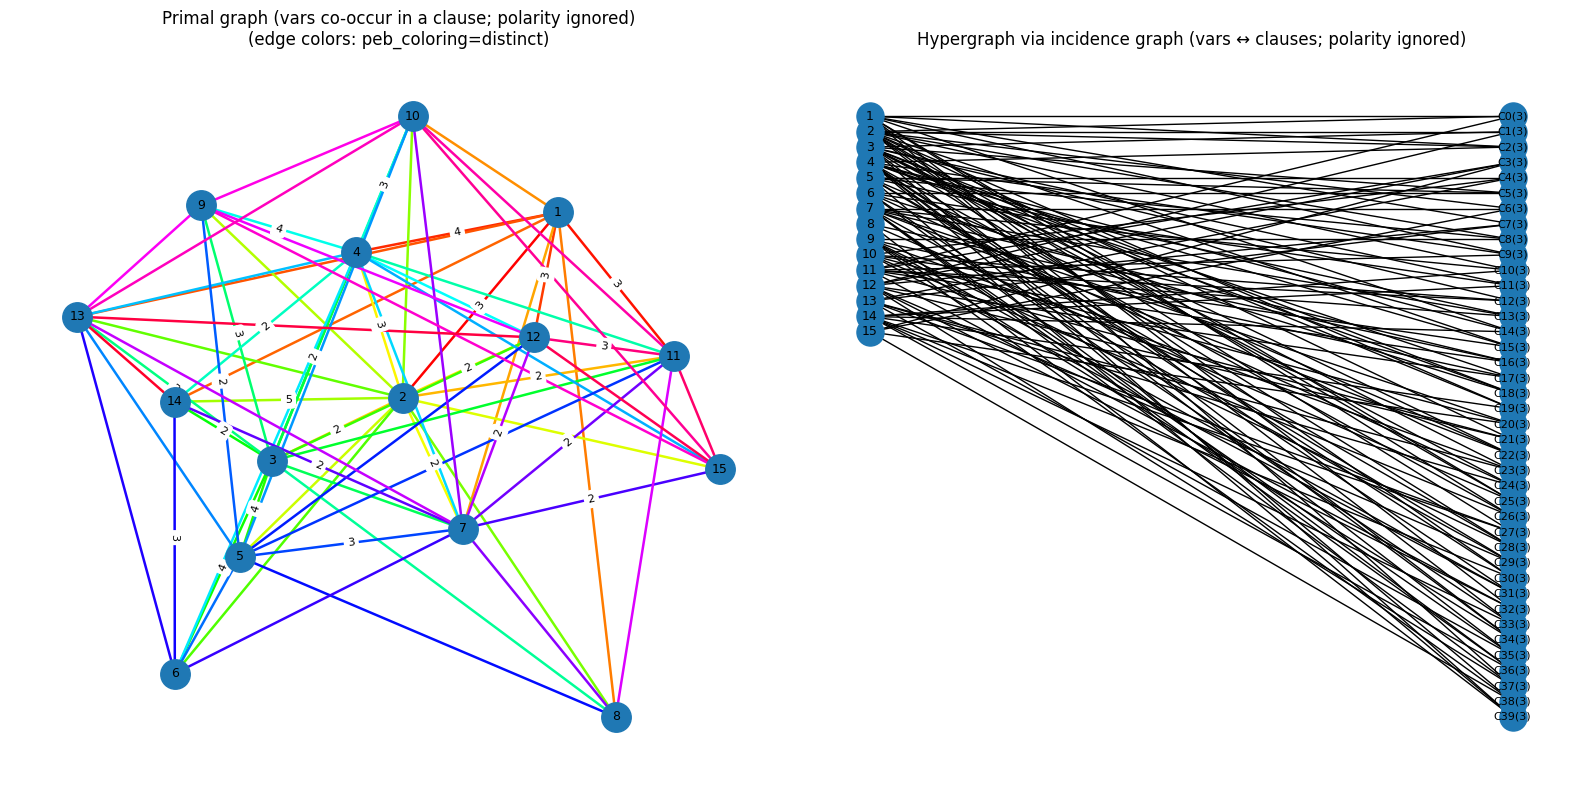

(<networkx.classes.graph.Graph at 0x7dc4db2c4f70>,
 <networkx.classes.graph.Graph at 0x7dc4db2c4e50>)

In [ ]:
# Add these imports near the top (you already have plt)
import random
import matplotlib.colors as mcolors

from typing import List, Optional, Sequence, Dict, Tuple
from collections import Counter
from cnf import *
import matplotlib.pyplot as plt

try:
    import networkx as nx
except ImportError as e:
    raise ImportError("Requires networkx. In a notebook run: !pip install networkx") from e


def infer_num_vars(clauses: List[List[int]]) -> int:
    return max((abs(l) for c in clauses for l in c), default=0)


def build_primal_graph(
    clauses: List[List[int]],
    *,
    weighted: bool = True,
) -> nx.Graph:
    """
    Primal graph:
      - nodes: variables 1..n
      - edge (u,v): u and v appear together in a clause (polarity ignored)
      - weight: number of clauses where {u,v} co-occur (if weighted=True)
    """
    n = infer_num_vars(clauses)
    G = nx.Graph()
    G.add_nodes_from(range(1, n + 1))

    co = Counter()
    for c in clauses:
        vs = sorted(set(abs(l) for l in c))
        for i in range(len(vs)):
            for j in range(i + 1, len(vs)):
                co[(vs[i], vs[j])] += 1

    for (u, v), w in co.items():
        if weighted:
            G.add_edge(u, v, weight=w)
        else:
            G.add_edge(u, v)

    return G


def build_incidence_graph(
    clauses: List[List[int]],
) -> nx.Graph:
    """
    Hypergraph visualization via incidence graph:
      - variable nodes: "v:1", ..., "v:n"
      - clause nodes: "c:0", ..., "c:m-1"
      - edge between clause node and each variable appearing in that clause (polarity ignored)
    Stores attributes:
      - kind in {"var","clause"}
      - var_id (int) for var nodes
      - clause_id (int) and clause_size (int) for clause nodes
    """
    n = infer_num_vars(clauses)
    B = nx.Graph()

    for v in range(1, n + 1):
        B.add_node(f"v:{v}", kind="var", var_id=v)

    for ci, c in enumerate(clauses):
        cn = f"c:{ci}"
        vs = sorted(set(abs(l) for l in c))
        B.add_node(cn, kind="clause", clause_id=ci, clause_size=len(vs))
        for v in vs:
            B.add_edge(f"v:{v}", cn)

    return B

def visualize_cnf_graphs(
    clauses: List[List[int]],
    *,
    primal_weighted: bool = True,
    show_primal_weights: bool = True,
    max_label_vars: int = 60,
    primal_layout: str = "spring",   # "spring" | "kamada_kawai" | "spectral"
    seed: int = 0,
    figsize: Tuple[int, int] = (16, 8),
    peb_coloring: Optional[str] = None,  # None | "random" | "distinct" | "level" | "merge"
    peb_root: Optional[int] = None,      # optionally force root for "level"
) -> Tuple[nx.Graph, nx.Graph]:
    """
    Draws:
      (1) Primal graph (variables only)
      (2) Hypergraph via incidence graph (variables ↔ clauses)

    peb_coloring options for primal edges:
      - None       : old PHP-like block coloring (if block_size inferred), else gray
      - "random"   : random colors sampled from a large palette (not guaranteed unique)
      - "distinct" : per-edge distinct hues (HSV sweep)
      - "level"    : color by distance-from-root levels (root defaults to max var id unless peb_root given)
      - "merge"    : highlight edges incident to high-degree "merge" nodes
    """
    if not clauses:
        raise ValueError("clauses is empty")

    Gp = build_primal_graph(clauses, weighted=primal_weighted)
    Bi = build_incidence_graph(clauses)

    # --- Infer "pigeon block size" if possible (works for PHP-like encodings) ---
    pos_clause_sizes = [len(set(abs(l) for l in c)) for c in clauses if all(l > 0 for l in c)]
    block_size = max(pos_clause_sizes) if pos_clause_sizes else None

    layout_fns = {
        "spring": lambda G: nx.spring_layout(G, seed=seed, k=1.2),
        "kamada_kawai": lambda G: nx.kamada_kawai_layout(G),
        "spectral": lambda G: nx.spectral_layout(G),
    }
    if primal_layout not in layout_fns:
        raise ValueError(f"Unknown primal_layout={primal_layout!r}. Use {list(layout_fns)}.")

    fig, axs = plt.subplots(1, 2, figsize=figsize)

    # ---------------- (1) Primal graph ----------------
    ax = axs[0]
    pos = layout_fns[primal_layout](Gp)

    nx.draw_networkx_nodes(Gp, pos, ax=ax, node_size=450)

    edges = list(Gp.edges())

    # --- Edge coloring toggle ---
    edge_colors = None

    if peb_coloring == "random":
        rng = random.Random(seed)
        palette = (
            list(mcolors.TABLEAU_COLORS.values())
            + list(mcolors.BASE_COLORS.values())
            + list(mcolors.CSS4_COLORS.values())
        )
        edge_colors = [rng.choice(palette) for _ in edges]

    elif peb_coloring == "distinct":
        # Guaranteed distinct hues by index
        if len(edges) == 0:
            edge_colors = []
        else:
            edge_colors = [plt.cm.hsv(i / max(1, len(edges))) for i in range(len(edges))]

    elif peb_coloring == "level":
        # Color edges by distance from a chosen root in the primal graph
        if Gp.number_of_nodes() == 0:
            edge_colors = []
        else:
            root = peb_root if peb_root is not None else max(Gp.nodes())
            # If graph disconnected, this returns levels for reachable nodes only
            levels = nx.single_source_shortest_path_length(Gp, root)
            if not levels:
                # fallback: all gray
                edge_colors = ["0.5" for _ in edges]
            else:
                max_level = max(levels.values()) or 1
                edge_colors = []
                for u, v in edges:
                    lu = levels.get(u, max_level)
                    lv = levels.get(v, max_level)
                    level = max(lu, lv)
                    edge_colors.append(plt.cm.viridis(level / max_level))

    elif peb_coloring == "merge":
        # Highlight edges incident to high-degree nodes (merge points)
        edge_colors = []
        for u, v in edges:
            if Gp.degree(u) > 2 or Gp.degree(v) > 2:
                edge_colors.append("tab:red")
            else:
                edge_colors.append("tab:blue")

    else:
        # Original PHP-like coloring (if block_size inferred), else gray
        edge_colors = []
        for u, v in edges:
            if block_size and (u - 1) // block_size == (v - 1) // block_size:
                edge_colors.append("tab:blue")
            elif block_size:
                edge_colors.append("tab:red")
            else:
                edge_colors.append("0.5")

    nx.draw_networkx_edges(
        Gp,
        pos,
        ax=ax,
        edgelist=edges,
        edge_color=edge_colors,
        width=1.8,
        connectionstyle="arc3,rad=0.08",
    )

    if Gp.number_of_nodes() <= max_label_vars:
        nx.draw_networkx_labels(
            Gp,
            pos,
            labels={v: str(v) for v in Gp.nodes()},
            ax=ax,
            font_size=9,
        )

    # Only label edges with weight > 1
    if show_primal_weights and primal_weighted:
        edge_labels = {
            (u, v): d.get("weight", 1)
            for u, v, d in Gp.edges(data=True)
            if d.get("weight", 1) > 1
        }
        if edge_labels:
            nx.draw_networkx_edge_labels(Gp, pos, edge_labels=edge_labels, ax=ax, font_size=8)

    title = "Primal graph (vars co-occur in a clause; polarity ignored)"
    if peb_coloring:
        title += f"\n(edge colors: peb_coloring={peb_coloring})"
        if peb_coloring == "level":
            title += f"; root={peb_root if peb_root is not None else max(Gp.nodes())}"
    elif block_size:
        title += f"\n(edge colors: within-block=blue, cross-block=red; block_size≈{block_size})"
    ax.set_title(title)
    ax.axis("off")

    # ---------------- (2) Incidence graph ----------------
    ax = axs[1]
    var_nodes = [n for n, d in Bi.nodes(data=True) if d.get("kind") == "var"]
    clause_nodes = [n for n, d in Bi.nodes(data=True) if d.get("kind") == "clause"]

    var_nodes_sorted = sorted(var_nodes, key=lambda n: Bi.nodes[n]["var_id"])
    clause_nodes_sorted = sorted(clause_nodes, key=lambda n: Bi.nodes[n]["clause_id"])

    pos2: Dict[str, Tuple[float, float]] = {}
    for i, n in enumerate(var_nodes_sorted):
        pos2[n] = (0.0, -i)
    for i, n in enumerate(clause_nodes_sorted):
        pos2[n] = (4.0, -i)

    nx.draw_networkx_edges(Bi, pos2, ax=ax, width=1)
    nx.draw_networkx_nodes(Bi, pos2, nodelist=var_nodes_sorted, ax=ax, node_size=380)
    nx.draw_networkx_nodes(Bi, pos2, nodelist=clause_nodes_sorted, ax=ax, node_size=380)

    if len(var_nodes_sorted) <= max_label_vars:
        nx.draw_networkx_labels(
            Bi,
            pos2,
            labels={n: str(Bi.nodes[n]["var_id"]) for n in var_nodes_sorted},
            ax=ax,
            font_size=9,
        )
    if len(clause_nodes_sorted) <= 80:
        nx.draw_networkx_labels(
            Bi,
            pos2,
            labels={n: f"C{Bi.nodes[n]['clause_id']}({Bi.nodes[n]['clause_size']})" for n in clause_nodes_sorted},
            ax=ax,
            font_size=8,
        )

    ax.set_title("Hypergraph via incidence graph (vars ↔ clauses; polarity ignored)")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    return Gp, Bi

clauses, nv = read_cnf("peb.cnf")
clauses, nv = build_random_kcnf(10, 25, 3, seed=42) 

visualize_cnf_graphs(clauses, peb_coloring="distinct")
